# Elliptic Bitcoin Data Discovery


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
from torch_geometric.utils import degree
import warnings
warnings.filterwarnings("ignore")

## Load Data

In [2]:
DATA_DIR = Path('../data/raw')

feat_path = DATA_DIR / 'elliptic_txs_features.csv'
class_path = DATA_DIR / 'elliptic_txs_classes.csv'
edge_path = DATA_DIR / 'elliptic_txs_edgelist.csv'

files_exist = all([feat_path.exists(), class_path.exists(), edge_path.exists()])

if not files_exist:
    print("Missing files. Download from Kaggle:")
    print(f"  - {feat_path}")
    print(f"  - {class_path}")
    print(f"  - {edge_path}")
else:
    print("All files found.")

All files found.


In [3]:
# Load features (no header)
df_feat = pd.read_csv(feat_path, header=None)
print(f"Features shape: {df_feat.shape}")
df_feat.head()

Features shape: (203769, 167)


,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


Column 0 = transaction ID, Column 1 = time step, Columns 2-167 = 166 features.

In [4]:
# Load classes
df_class = pd.read_csv(class_path)
print(f"Classes shape: {df_class.shape}")
df_class.head()

Classes shape: (203769, 2)


,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


In [5]:
# Load edges
df_edge = pd.read_csv(edge_path)
print(f"Edges shape: {df_edge.shape}")
df_edge.head()

Edges shape: (234355, 2)


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


##  Basic Statistics

In [6]:
tx_ids = df_feat.iloc[:, 0].values
time_steps = df_feat.iloc[:, 1].values
features = df_feat.iloc[:, 2:].values

print(f"Transactions (nodes): {len(tx_ids):,}")
print(f"Features per transaction: {features.shape[1]}")
print(f"Edges: {len(df_edge):,}")
print(f"Time steps: {len(np.unique(time_steps))}")

Transactions (nodes): 203,769
Features per transaction: 165
Edges: 234,355
Time steps: 49


In [7]:
avg_degree = (2 * len(df_edge)) / len(tx_ids)
print(f"Average degree: {avg_degree:.2f}")

Average degree: 2.30


Large Bitcoin transaction network with ~200K nodes and 165 anonymized features per transaction.

## Class Distribution

In [8]:
class_counts = df_class['class'].value_counts()
print("Class distribution:")
for c, cnt in class_counts.items():
    print(f"  {c}: {cnt:,} ({cnt/len(df_class)*100:.2f}%)")

Class distribution:
  unknown: 157,205 (77.15%)
  2: 42,019 (20.62%)
  1: 4,545 (2.23%)


Classes:
- `1`: Licit (legitimate)
- `2`: Illicit (fraud/criminal)
- `unknown`: Unlabeled


In [9]:
# Labeled only
labeled = df_class[df_class['class'] != 'unknown']['class'].astype(int)
n_licit = (labeled == 1).sum()
n_illicit = (labeled == 2).sum()
n_labeled = n_licit + n_illicit

print(f"Labeled: {n_labeled:,}")
print(f"  Licit: {n_licit:,} ({n_licit/n_labeled*100:.2f}%)")
print(f"  Illicit: {n_illicit:,} ({n_illicit/n_labeled*100:.2f}%)")

Labeled: 46,564
  Licit: 4,545 (9.76%)
  Illicit: 42,019 (90.24%)


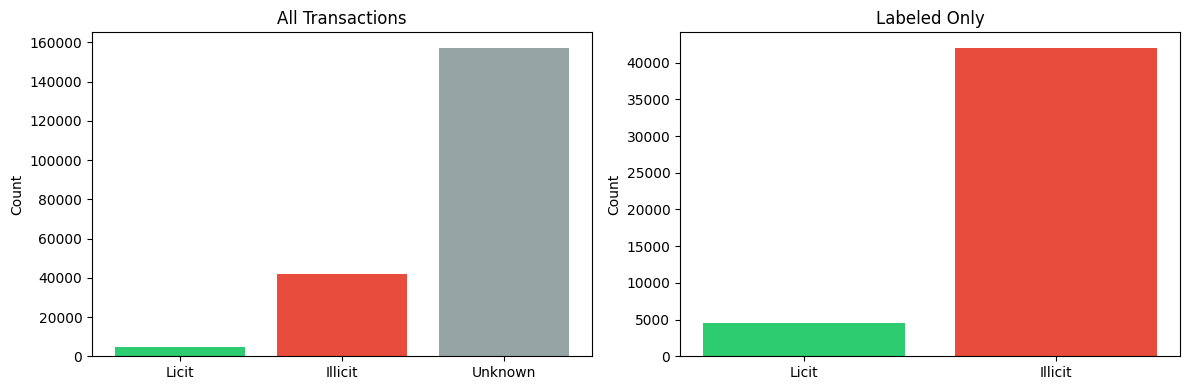

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# All classes
ax = axes[0]
ax.bar(['Licit', 'Illicit', 'Unknown'],
       [class_counts.get('1', 0), class_counts.get('2', 0), class_counts.get('unknown', 0)],
       color=['#2ecc71', '#e74c3c', '#95a5a6'])
ax.set_ylabel('Count')
ax.set_title('All Transactions')

# Labeled only
ax = axes[1]
ax.bar(['Licit', 'Illicit'], [n_licit, n_illicit], color=['#2ecc71', '#e74c3c'])
ax.set_ylabel('Count')
ax.set_title('Labeled Only')

plt.tight_layout()
plt.show()

## Temporal Analysis

In [11]:
print(f"Time steps: {time_steps.min()} to {time_steps.max()}")
print(f"Unique time steps: {len(np.unique(time_steps))}")

Time steps: 1 to 49
Unique time steps: 49


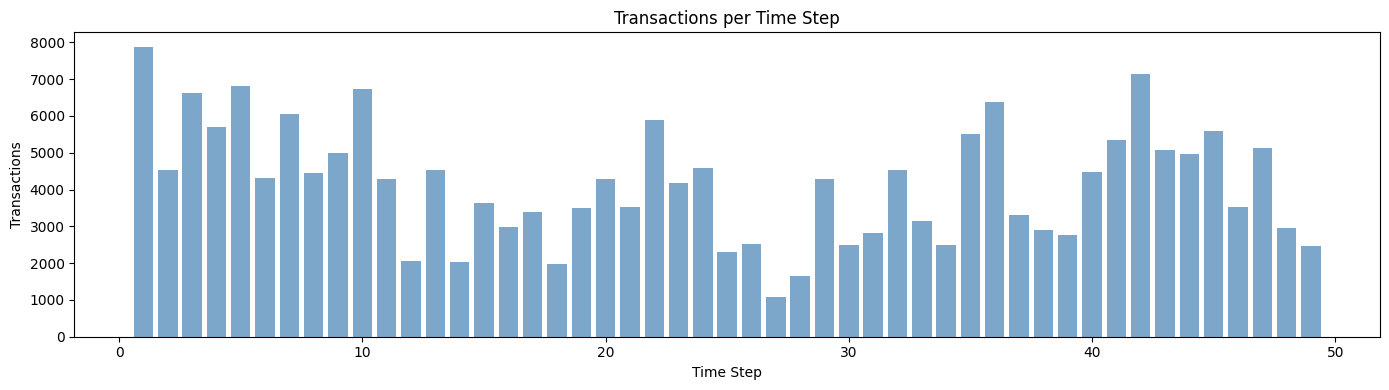

In [12]:
# Transactions per time step
tx_per_step = pd.Series(time_steps).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(tx_per_step.index, tx_per_step.values, color='steelblue', alpha=0.7)
ax.set_xlabel('Time Step')
ax.set_ylabel('Transactions')
ax.set_title('Transactions per Time Step')
plt.tight_layout()
plt.show()

In [13]:
# Illicit ratio over time
df_temp = pd.DataFrame({'txId': tx_ids, 'time': time_steps})
df_merged = df_temp.merge(df_class, on='txId', how='left')

labeled_df = df_merged[df_merged['class'] != 'unknown'].copy()
labeled_df['class'] = labeled_df['class'].astype(int)
labeled_df['is_illicit'] = (labeled_df['class'] == 2).astype(int)

illicit_time = labeled_df.groupby('time')['is_illicit'].agg(['sum', 'count'])
illicit_time['ratio'] = illicit_time['sum'] / illicit_time['count']

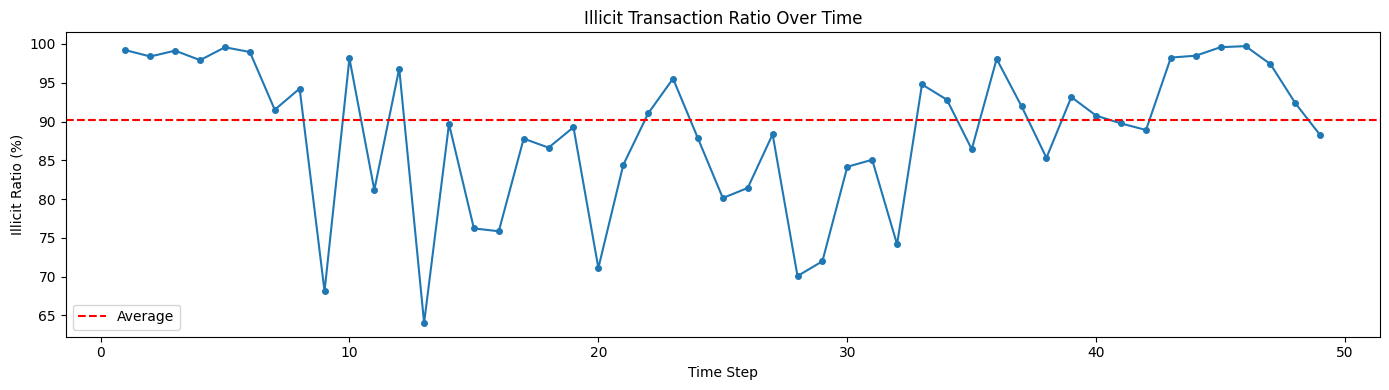

In [14]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(illicit_time.index, illicit_time['ratio'] * 100, marker='o', markersize=4)
ax.axhline(n_illicit/n_labeled*100, color='red', linestyle='--', label='Average')
ax.set_xlabel('Time Step')
ax.set_ylabel('Illicit Ratio (%)')
ax.set_title('Illicit Transaction Ratio Over Time')
ax.legend()
plt.tight_layout()
plt.show()

##  Feature Analysis

In [15]:
# Basic stats
df_feat_stats = pd.DataFrame(features)
df_feat_stats.describe()

,0,1,2,3,4,5,6,7,8,9,...,155,156,157,158,159,160,161,162,163,164
count,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,...,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05
mean,2.008513e-17,1.785345e-17,3.570689e-17,6.862418e-17,7.810883e-17,5.802370e-17,2.566433e-17,3.124353e-17,4.463361e-17,4.658634e-17,...,-2.789601e-17,1.612389e-16,-8.480387e-17,6.695042e-17,-4.686530e-17,-2.231681e-18,5.356034e-17,1.785345e-17,3.570689e-17,6.025538e-17
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,...,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-1.729826e-01,-2.105526e-01,-1.756361e+00,-1.219696e-01,-6.372457e-02,-1.130020e-01,-6.158379e-02,-1.636459e-01,-1.694603e-01,-4.970696e-02,...,-5.770994e-01,-6.262286e-01,-9.790738e-01,-9.785560e-01,-2.160569e-01,-1.259391e-01,-1.311553e-01,-2.698175e-01,-1.760926e+00,-1.760984e+00
25%,-1.725317e-01,-1.803266e-01,-1.201369e+00,-1.219696e-01,-4.387455e-02,-1.130020e-01,-6.158379e-02,-1.635168e-01,-1.690701e-01,-4.970696e-02,...,-5.696264e-01,-5.946915e-01,-9.790738e-01,-9.785560e-01,-9.888874e-02,-8.749016e-02,-1.311553e-01,-1.405971e-01,-1.206134e-01,-1.197925e-01
50%,-1.692045e-01,-1.328975e-01,4.636092e-01,-1.219696e-01,-4.387455e-02,-1.130020e-01,-6.158379e-02,-1.620440e-01,-1.662255e-01,-4.970696e-02,...,-4.799511e-01,-4.559278e-01,2.411283e-01,2.414064e-01,1.827940e-02,-8.749016e-02,-1.311553e-01,-9.752359e-02,-1.206134e-01,-1.197925e-01
75%,-1.318553e-01,-5.524241e-02,1.018602e+00,-1.219696e-01,-4.387455e-02,-1.130020e-01,-6.158379e-02,-1.355932e-01,-1.323665e-01,-4.970696e-02,...,1.552495e-01,1.212026e-01,1.305594e+00,1.398764e+00,1.827940e-02,-8.749016e-02,-8.467423e-02,-9.752359e-02,1.520067e-01,1.199710e-01
max,7.168197e+01,7.359505e+01,2.683580e+00,4.902760e+01,2.600907e+02,5.456518e+01,1.134409e+02,7.335457e+01,7.231840e+01,1.891869e+02,...,7.862953e+00,7.914041e+00,1.461330e+00,1.461369e+00,1.170692e+02,2.518490e+02,2.387835e+02,1.057340e+02,1.519700e+00,1.521399e+00


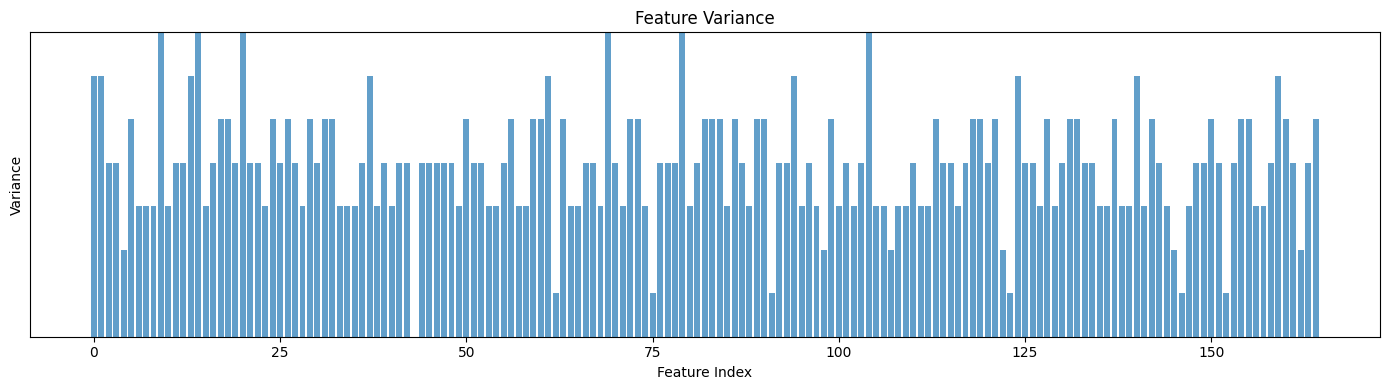

In [16]:
# Feature variance
feat_var = df_feat_stats.var()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(feat_var)), feat_var.values, alpha=0.7)
ax.set_xlabel('Feature Index')
ax.set_ylabel('Variance')
ax.set_title('Feature Variance')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

Features have varying variance - normalization will be needed during preprocessing.

In [17]:
# Compare licit vs illicit features
class_map = df_class.set_index('txId')['class'].to_dict()
labels = np.array([class_map.get(tx, 'unknown') for tx in tx_ids])

licit_mask = labels == '1'
illicit_mask = labels == '2'

feat_licit = features[licit_mask]
feat_illicit = features[illicit_mask]

print(f"Licit: {feat_licit.shape[0]:,}")
print(f"Illicit: {feat_illicit.shape[0]:,}")

Licit: 4,545
Illicit: 42,019


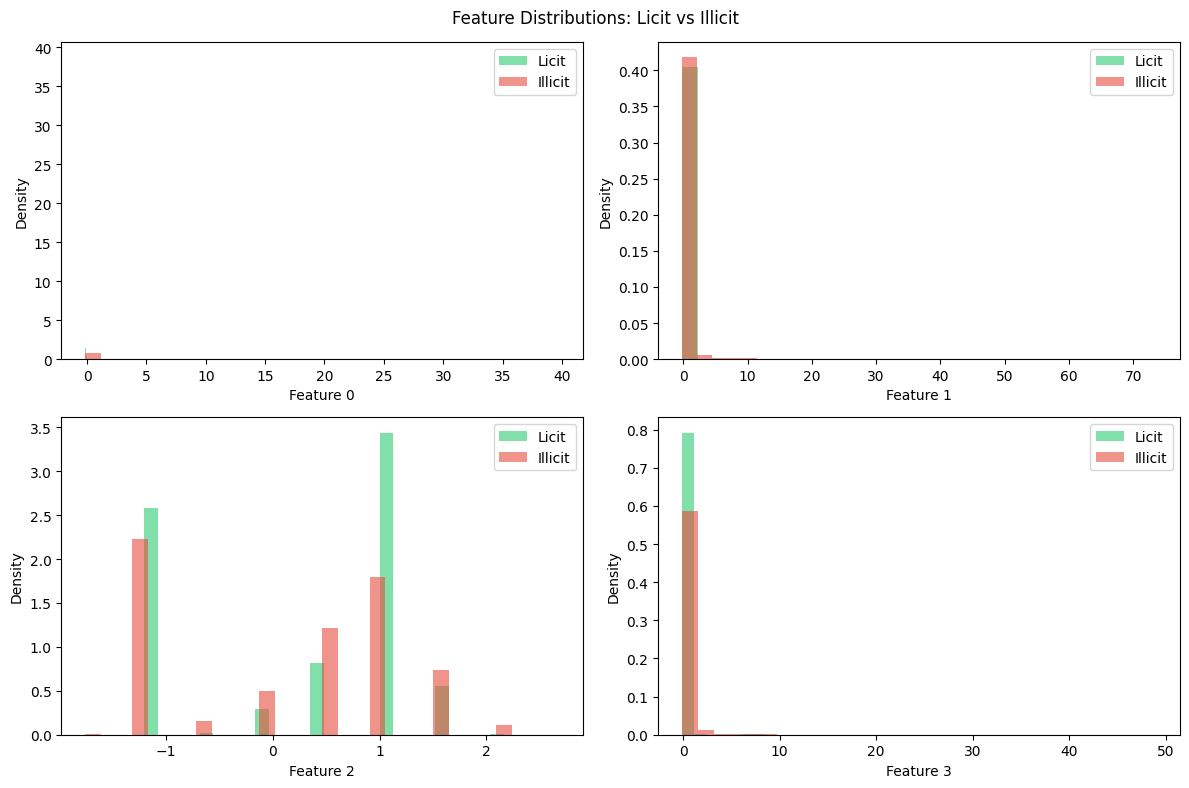

In [18]:
# Plot first 4 features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i in range(4):
    ax = axes[i]
    ax.hist(feat_licit[:, i], bins=30, alpha=0.6, label='Licit', color='#2ecc71', density=True)
    ax.hist(feat_illicit[:, i], bins=30, alpha=0.6, label='Illicit', color='#e74c3c', density=True)
    ax.set_xlabel(f'Feature {i}')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Feature Distributions: Licit vs Illicit')
plt.tight_layout()
plt.show()

##  Graph Structure

In [19]:
# Build node index mapping
id_to_idx = {tx: i for i, tx in enumerate(tx_ids)}

# Map edges
src_ids = df_edge.iloc[:, 0].values
dst_ids = df_edge.iloc[:, 1].values

valid_edges = [(id_to_idx[s], id_to_idx[d]) for s, d in zip(src_ids, dst_ids)
               if s in id_to_idx and d in id_to_idx]

src_idx = [e[0] for e in valid_edges]
dst_idx = [e[1] for e in valid_edges]

print(f"Valid edges: {len(valid_edges):,}")

Valid edges: 234,355


In [20]:
edge_index = torch.tensor([src_idx, dst_idx], dtype=torch.long)
num_nodes = len(tx_ids)

in_deg = degree(edge_index[1], num_nodes=num_nodes).numpy()
out_deg = degree(edge_index[0], num_nodes=num_nodes).numpy()

print(f"In-degree: min={in_deg.min():.0f}, max={in_deg.max():.0f}, mean={in_deg.mean():.2f}")
print(f"Out-degree: min={out_deg.min():.0f}, max={out_deg.max():.0f}, mean={out_deg.mean():.2f}")

In-degree: min=0, max=284, mean=1.15
Out-degree: min=0, max=472, mean=1.15


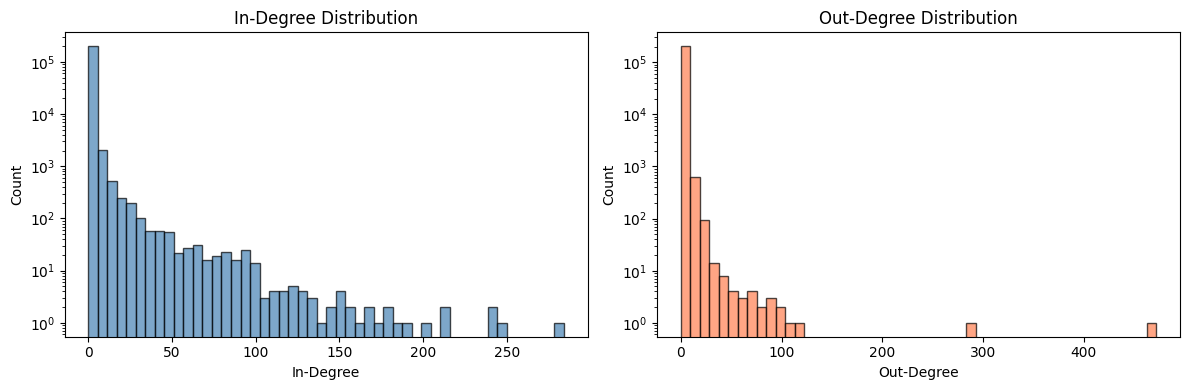

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(in_deg, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('In-Degree')
axes[0].set_ylabel('Count')
axes[0].set_title('In-Degree Distribution')
axes[0].set_yscale('log')

axes[1].hist(out_deg, bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Out-Degree')
axes[1].set_ylabel('Count')
axes[1].set_title('Out-Degree Distribution')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

##  Edge Homophily

In [22]:
# Compute homophily on labeled edges
same_label = 0
total_labeled = 0

for s, d in valid_edges:
    s_lbl = labels[s]
    d_lbl = labels[d]
    if s_lbl in ['1', '2'] and d_lbl in ['1', '2']:
        total_labeled += 1
        if s_lbl == d_lbl:
            same_label += 1

homophily = same_label / total_labeled if total_labeled > 0 else 0
print(f"Edge homophily (labeled): {homophily:.4f}")

Edge homophily (labeled): 0.9537


##  Temporal Split Strategy

In [23]:
unique_times = np.sort(np.unique(time_steps))

# 60/20/20 temporal split
train_cut = unique_times[int(0.6 * len(unique_times))]
val_cut = unique_times[int(0.8 * len(unique_times))]

print(f"Train: steps 1-{train_cut}")
print(f"Val: steps {train_cut+1}-{val_cut}")
print(f"Test: steps {val_cut+1}-{unique_times[-1]}")

Train: steps 1-30
Val: steps 31-40
Test: steps 41-49


In [24]:
# Count per split
train_mask = (time_steps <= train_cut) & (labels != 'unknown')
val_mask = (time_steps > train_cut) & (time_steps <= val_cut) & (labels != 'unknown')
test_mask = (time_steps > val_cut) & (labels != 'unknown')

print(f"Train: {train_mask.sum():,}")
print(f"Val: {val_mask.sum():,}")
print(f"Test: {test_mask.sum():,}")

Train: 26,905
Val: 9,686
Test: 9,973


In [25]:
# Illicit ratio per split
num_labels = np.where(labels == '2', 1, np.where(labels == '1', 0, -1))

train_ill = (num_labels[train_mask] == 1).sum() / train_mask.sum() * 100
val_ill = (num_labels[val_mask] == 1).sum() / val_mask.sum() * 100
test_ill = (num_labels[test_mask] == 1).sum() / test_mask.sum() * 100

print(f"Illicit ratio - Train: {train_ill:.2f}%, Val: {val_ill:.2f}%, Test: {test_ill:.2f}%")

Illicit ratio - Train: 89.02%, Val: 88.98%, Test: 94.75%


##  Summary

In [26]:
summary = {
    'Metric': ['Nodes', 'Edges', 'Features', 'Time Steps', 'Labeled',
               'Licit', 'Illicit', 'Illicit Rate', 'Avg Degree', 'Homophily'],
    'Value': [
        f"{len(tx_ids):,}",
        f"{len(valid_edges):,}",
        166,
        len(unique_times),
        f"{n_labeled:,}",
        f"{n_licit:,}",
        f"{n_illicit:,}",
        f"{n_illicit/n_labeled*100:.2f}%",
        f"{avg_degree:.2f}",
        f"{homophily:.4f}"
    ]
}
pd.DataFrame(summary)

,Metric,Value
0,Nodes,"203,769"
1,Edges,"234,355"
2,Features,166
3,Time Steps,49
4,Labeled,"46,564"
5,Licit,"4,545"
6,Illicit,"42,019"
7,Illicit Rate,90.24%
8,Avg Degree,2.30
9,Homophily,0.9537
